# 02 · Modelado predictivo
Entrada: `data/processed/jugadores_clean.csv`
Salida: modelo entrenado + partición (en `models/`), figura de coeficientes.

Flujo: split estratificado → pipeline (scaler + modelo) → logística vs RF →
interpretación de coeficientes → comprobación contra los pesos de la simulación.

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

ROOT = Path("..")
FIGS = ROOT / "figures"
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "font.size": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "savefig.bbox": "tight",
})
ANCHO = 6.3

METRICAS = ["PrecisionPase", "VelReaccion", "Efectividad1v1", "VelSprint",
            "DistAltaInt", "AciertoRegate", "Recuperaciones", "TomaDecision"]
ETIQUETAS = {
    "PrecisionPase": "Precisión de pase", "VelReaccion": "Vel. reacción",
    "Efectividad1v1": "Efectividad 1v1", "VelSprint": "Vel. sprint",
    "DistAltaInt": "Dist. alta intensidad", "AciertoRegate": "Acierto regate",
    "Recuperaciones": "Recuperaciones", "TomaDecision": "Toma de decisión",
}

dfc = pd.read_csv(ROOT / "data/processed/jugadores_clean.csv")
X = dfc[METRICAS]
y = dfc["AltoPotencial"]

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=7
)

print(f"Train: {len(y_tr)} jugadores, {y_tr.mean():.0%} positivos")
print(f"Test:  {len(y_te)} jugadores, {y_te.mean():.0%} positivos")

Train: 28 jugadores, 36% positivos
Test:  12 jugadores, 33% positivos


In [11]:
pipe_logit = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000)),
])

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),   # el RF no lo necesita, pero unifica el flujo
    ("modelo", RandomForestClassifier(n_estimators=300, random_state=7)),
])

pipe_logit.fit(X_tr, y_tr)
pipe_rf.fit(X_tr, y_tr)

,steps,"[('scaler', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [12]:
for nombre, pipe in [("Logística", pipe_logit), ("Random Forest", pipe_rf)]:
    acc_tr = pipe.score(X_tr, y_tr)
    acc_te = pipe.score(X_te, y_te)
    print(f"{nombre:14s} · accuracy train: {acc_tr:.2f} | test: {acc_te:.2f}")

Logística      · accuracy train: 0.82 | test: 0.67
Random Forest  · accuracy train: 1.00 | test: 0.58


VelReaccion      -0.460
DistAltaInt       0.094
Recuperaciones    0.160
VelSprint         0.255
Efectividad1v1    0.337
AciertoRegate     0.380
PrecisionPase     0.754
TomaDecision      1.088
dtype: float64

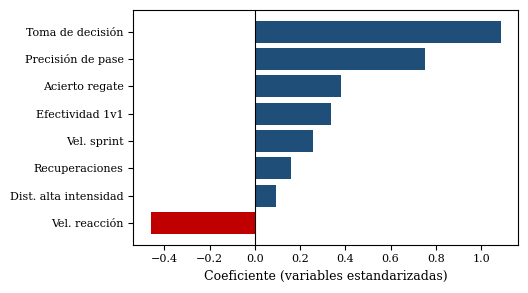

In [13]:
coefs = pd.Series(
    pipe_logit.named_steps["modelo"].coef_[0],
    index=METRICAS,
).sort_values()

fig, ax = plt.subplots(figsize=(ANCHO * 0.85, 3.0))
colores = ["#c00000" if v < 0 else "#1f4e79" for v in coefs]
ax.barh([ETIQUETAS[i] for i in coefs.index], coefs, color=colores)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Coeficiente (variables estandarizadas)")
fig.tight_layout()
fig.savefig(FIGS / "fig4_coeficientes.pdf")

coefs.round(3)

In [14]:
top = ranking.head(8)[["Jugador", "Posicion", "Edad", "PrecisionPase",
                       "VelReaccion", "Efectividad1v1", "TomaDecision",
                       "ProbPotencial"]]
top.columns = ["Jugador", "Posición", "Edad", "Pase (\\%)", "Reacción (s)",
               "1v1 (\\%)", "Decisión", "Prob."]
top.style.hide(axis="index").format(precision=2).to_latex(
    ROOT / "informe/tablas/tab_ranking.tex", hrules=True)

In [15]:
PESOS = {   # los mismos que en src/generar_datos.py
    "PrecisionPase": 0.28, "VelReaccion": -0.30, "Efectividad1v1": 0.25,
    "VelSprint": 0.12, "DistAltaInt": 0.10, "AciertoRegate": 0.18,
    "Recuperaciones": 0.08, "TomaDecision": 0.26,
}

comp = pd.DataFrame({
    "peso_verdadero": pd.Series(PESOS),
    "coef_modelo": coefs,
})
# Normalizamos ambos (norma 1) para comparar solo la ESTRUCTURA, no la escala
for c in comp:
    comp[c + "_norm"] = comp[c] / np.linalg.norm(comp[c])

print(comp.round(3).sort_values("peso_verdadero", ascending=False))
print("\nCorrelación pesos vs coeficientes:",
      f"{comp.peso_verdadero.corr(comp.coef_modelo):.2f}")

                peso_verdadero  coef_modelo  peso_verdadero_norm  \
PrecisionPase             0.28        0.754                0.466   
TomaDecision              0.26        1.088                0.432   
Efectividad1v1            0.25        0.337                0.416   
AciertoRegate             0.18        0.380                0.299   
VelSprint                 0.12        0.255                0.200   
DistAltaInt               0.10        0.094                0.166   
Recuperaciones            0.08        0.160                0.133   
VelReaccion              -0.30       -0.460               -0.499   

                coef_modelo_norm  
PrecisionPase              0.495  
TomaDecision               0.714  
Efectividad1v1             0.221  
AciertoRegate              0.249  
VelSprint                  0.168  
DistAltaInt                0.062  
Recuperaciones             0.105  
VelReaccion               -0.302  

Correlación pesos vs coeficientes: 0.87


In [16]:
dfc["ProbPotencial"] = pipe_logit.predict_proba(X)[:, 1].round(3)

ranking = dfc.sort_values("ProbPotencial", ascending=False)
ranking[["Jugador", "Posicion", "Edad", "ProbPotencial", "AltoPotencial"]].head(10)

,Jugador,Posicion,Edad,ProbPotencial,AltoPotencial
30,J31,Extremo,18,0.949,1
20,J21,Delantero,19,0.903,0
12,J13,Defensa,17,0.901,1
27,J28,Extremo,19,0.868,1
2,J03,Extremo,16,0.787,1
29,J30,Delantero,16,0.771,1
32,J33,Centrocampista,19,0.712,0
22,J23,Extremo,19,0.709,1
34,J35,Delantero,16,0.619,1
16,J17,Defensa,16,0.489,0


In [17]:
joblib.dump({
    "pipe_logit": pipe_logit,
    "pipe_rf": pipe_rf,
    "X_tr": X_tr, "X_te": X_te, "y_tr": y_tr, "y_te": y_te,
}, MODELS / "modelado.joblib")
print("OK → models/modelado.joblib")

OK → models/modelado.joblib
